In [1]:
from PBR import PBR
from KineticModel import KineticModel
from Reaction import Reaction
import numpy as np
from y_n import y_n
from upsilon_n import upsilon_n
from math import e
from sklearn.model_selection import ParameterGrid
import pandas as pd
from IPython.display import clear_output
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
parafins = [ 'methane', 'ethane', 'propane', 
             'butane', 'pentane', 'hexane', 
               'heptane', 'octane', 
             'nonane', 'decane', 'undecane', 'dodecane',
               'tridecane', 'tetradecane', 'pentadecane', 'hexadecane', 'heptadecane',
               'octadecane', 'nonadecane', 'eicosane', 'heneicosane', 'docosane',
               'tricosane', 'tetracosane', 'pentacosane',
               'hexacosane', 'heptacosane',
               'octacosane', 'nonacosane', 'triacontane',
             'hentriacontane', 'dotriacontane',
               'tritriacontane', 'tetratriacontane', 'pentatriacontane', 'hexatriacontane'
            ]

olefins = [ 'ethylene',
            'propene',
            '1-butene', '1-pentene', '1-hexene',
            '1-heptene', '1-octene', 
            '1-nonene', '1-decene',
            '1-undecene', '1-dodecene',
            '1-tridecene', '1-tetradecene', '1-pentadecene',
            '1-hexadecene', '1-heptadecene', '1-octadecene',
          ]

others = ['carbon monoxide', 'hydrogen', 'water', 'carbon dioxide']

In [3]:
def Mousavi(eff):
    model_name = 'Mousavi'
    param_dict = {'k_ads': np.float64(1.397972209918762e-05),
                     'H_ads': np.float64(932.9790718460237),
                     'A_HCs': np.float64(955.0608601894231),
                     'E_HCs': np.float64(147203.9259840268),
                     'A_WGS': np.float64(2066275395.2988818),
                     'E_WGS': np.float64(164536.37699675243),
                     'a_WGS': np.float64(0.016649380568140318),
                     'b_WGS': np.float64(0.5269130869163346)}

    bnds = {
        'k_ads': (0, None), # 1/Pa
        'H_ads': (0, None), # J/mol
        'A_HCs': (0, None), # mol/s/kg/Pa²
        'E_HCs': (0, None), # J/mol
        'A_WGS': (0, None), # mol/s/kg/Pa²
        'E_WGS': (0, None), # J/mol
        'a_WGS': (None, None),
        'b_WGS': (None, None),
    }

    model = KineticModel(model_name, params = param_dict, bnds = bnds)

    def rate_WGS(param_dict, T, P, x, F, K, eq_distance, R, data):
        P_CO = x['carbon monoxide']*P
        P_H2O = x['water']*P
        P_CO2 = x['carbon dioxide']*P
        P_H2 = x['hydrogen']*P

        A_WGS = param_dict['A_WGS']
        E_WGS = param_dict['E_WGS']
        a = param_dict['a_WGS']
        b = param_dict['b_WGS']

        K_WGS = 1.45e-2 * np.exp( 4.62e3 / T )
        k_WGS = A_WGS * np.exp ( - E_WGS / ( 8.314 * T ) )

        rate_WGS = ( k_WGS * P_CO**a * P_H2O**b ) * eq_distance
        return rate_WGS

    WGS = Reaction(
                     name = 'WGS',
                     stoic = {
                             'carbon monoxide': -1,
                             'water': -1,
                             'carbon dioxide': 1,
                             'hydrogen': 1,
                         },
                     base_component = 'carbon monoxide',
                     rate_function = rate_WGS,
                     rate_unit = 'mol/s/kg',
                     eff_factor = eff,
        )

    model.add_reaction(WGS)

    n_parafins = {}
    for i, parafin in enumerate(parafins):
        n = i + 1
        n_parafins[parafin] = n

    n_olefins = {}
    for i, olefin in enumerate(olefins):
        n = i + 1
        n_olefins[olefin] = n

    for parafin in n_parafins:
        n = n_parafins[parafin]
        def rate_n_para(param_dict, T, P, x, F, K, eq_distance, R, data, n = n):
            P_H2 = x['hydrogen']*P
            P_CO = x['carbon monoxide']*P

            k_ads = param_dict['k_ads']
            H_ads = param_dict['H_ads']
            A_HCs = param_dict['A_HCs']
            E_HCs = param_dict['E_HCs']

            F_H2 = x['hydrogen']*F
            F_CO = x['carbon monoxide']*F

            K_ads = k_ads * e**(-H_ads / (R * T))
            k_HCs = A_HCs * e**(-E_HCs / (R * T))
            r     = y_n(n, T) * upsilon_n(n, T) * k_HCs * P_H2**0.75 * P_CO / (1 + K_ads * P_CO)**2
            return r

        reaction = Reaction(
                     name = parafin,
                     stoic = {
                             'carbon monoxide': -n,
                             'hydrogen': -(2*n + 1),
                              parafin: 1,
                             'water': n,
                         },
                     base_component = parafin,
                     rate_function = rate_n_para,
                     rate_unit = 'mol/s/kg',
                     eff_factor = eff,
        )

        model.add_reaction(reaction)

    for olefin in n_olefins:
        n = n_olefins[olefin]
        def rate_n_ole(param_dict, T, P, x, F, K, eq_distance, R, data, n = n):
            P_H2 = x['hydrogen']*P
            P_CO = x['carbon monoxide']*P

            k_ads = param_dict['k_ads']
            H_ads = param_dict['H_ads']
            A_HCs = param_dict['A_HCs']
            E_HCs = param_dict['E_HCs']

            F_H2 = x['hydrogen']*F
            F_CO = x['carbon monoxide']*F

            K_ads = k_ads * e**(-H_ads / (R * T))
            k_HCs = A_HCs * e**(-E_HCs / (R * T))
            r     = y_n(n, T) * (1 - upsilon_n(n, T)) * k_HCs * P_H2**0.75 * P_CO / (1 + K_ads * P_CO)**2
            return r

        reaction = Reaction(
                     name = olefin,
                     stoic = {
                             'carbon monoxide': -n,
                             'hydrogen': -(2*n),
                              olefin: 1,
                             'water': n,
                         },
                     base_component = olefin,
                     rate_function = rate_n_ole,
                     rate_unit = 'mol/s/kg',
                     eff_factor = eff,
        )

        model.add_reaction(reaction)
    return model

In [4]:
def solve_ODEs(index, row):
    results = {}
    F0 = row['F_H2_in'] + row['F_CO_in']

    H2_CO = 2
    x_CO = 1 / ( 1 + H2_CO )
    x_H2 = 1 - x_CO

    # create reactor object
    T0 = (row['T_K'], 'K')
    x0 = {
                      'carbon monoxide': x_CO,
                      'hydrogen' : x_H2,
                  }
    reactor = PBR(T0 = T0, 
                  P0 = (row['P_Pa'], 'Pa'), 
                  x0 = x0, 
                  F0 = (F0, 'mol/s'),
                  isothermal = True, 
                  ergun = False,
                  WT = (row['W_kg'], 'kg'), 
                  W_steps = 50,
                  U = (300, 'W/m2/K'),
                  D = (45.1, 'mm'),
                  Dp = (4, 'mm'),
                  pellet_density = (2530, 'kg/m3'),
                  Ta = T0,
                  liquid_phase = False,
                  units = 'SI',
                  solver_method = 'BDF',
                  rtol = 1e-5, atol = 1e-7,
                  calculate_equilibrium = False,
                  equilibrium_obj_fun_tolerance = 1e-12,
                  log = True,
                 )

    Mousavi_model = Mousavi(row['eff'])
    reactor.add_model(Mousavi_model)
    reactor.solve()

    sol_df = reactor.sol_dfs['Mousavi']

    for component in parafins + olefins + others:
        results[f'Fout_{component}'] = sol_df.loc[
            (sol_df.W == sol_df.W.max()) & (sol_df.variable == component)].value.values[-1]

    Q_unit = sol_df.loc[(sol_df.W == sol_df.W.max()) & (sol_df.variable == 'Q')]['value units'].values[-1]
    results[f'Q ({Q_unit})'] = sol_df.loc[(sol_df.W == sol_df.W.max()) & (sol_df.variable == 'Q')].value.values[-1]
    return index, results

In [5]:
v0 = 730 # L / min
v0 = v0 / ( 1000 * 60 ) # m3 / s

F0 = v0 * 1e5 / ( 8.314 * 273 ) # mol / s

H2_CO_in = 2
F_H2_in = F0 * (H2_CO_in / ( 1 + H2_CO_in )) # mol / s

param_grid = {'T_K'        : np.arange(210 + 273.15, 300 + 273.15, 10), 
              'P_Pa'       : np.arange(5e5, 35e5, 1e5),
              'F_H2_in'    : [F_H2_in],
              'F_CO_in'    : [0],
              'phi_220C'   : [0.001, 2, 4, 10],
              'W_kg'       : [74],
             }

parametric_data = pd.DataFrame(ParameterGrid(param_grid))
parametric_data.F_CO_in = F0 - parametric_data.F_H2_in
parametric_data['phi'] = parametric_data['phi_220C'] * ( 
        ( 493 / parametric_data['T_K'] ) * np.exp( - ( 147203.9 / 8.314 ) * ( 1/parametric_data['T_K'] - 1/493 ) ) 
    ) ** (1/2)
parametric_data['eff'] = np.tanh(parametric_data['phi'])/parametric_data['phi']

# Determine number of workers (e.g., 4 or use os.cpu_count())
num_workers = 4

print(f"Starting parallel simulation with {num_workers} workers...")

# Prepare the list of tasks
tasks = [(idx, row) for idx, row in parametric_data.iterrows()]

# Execute in parallel
results_list = []
with ProcessPoolExecutor(max_workers=num_workers) as executor:
    # We use a wrapper or starmap-like approach
    futures = [executor.submit(solve_ODEs, *task) for task in tasks]
    
    for future in tqdm(futures, total=len(futures)):
        idx, res = future.result()
        # Update the dataframe with results
        for col, val in res.items():
            parametric_data.loc[idx, col] = val

# Save final results
parametric_data.to_pickle('parity_parametric_data_PBRsim.pkl')
parametric_data.to_excel('parity_parametric_data_PBRsim.ods')
print("Simulations complete.")

In [6]:
parametric_data = pd.read_pickle('parity_parametric_data_PBRsim.pkl')

In [7]:
cols_Fout = [f'Fout_{comp}' for comp in parafins + olefins + others] 

In [8]:
from models_FTS.chain_length import n_parafins, n_olefins 

In [9]:
MM = {}
for comp in parafins:
    MM[f'Fout_{comp}'] = 12 * n_parafins[comp] + 2 * n_parafins[comp] + 2
for comp in olefins:
    MM[f'Fout_{comp}'] = 12 * n_olefins[comp] + 2 * n_olefins[comp]

In [10]:
cols_Fout_C1_C8 = ['Fout_methane',
 'Fout_ethane',
 'Fout_propane',
 'Fout_butane',
 'Fout_pentane',
 'Fout_hexane',
 'Fout_heptane',
 'Fout_octane',
 'Fout_ethylene',
 'Fout_propene',
 'Fout_1-butene',
 'Fout_1-pentene',
 'Fout_1-hexene',
 'Fout_1-heptene',
 'Fout_1-octene'
                  ]

In [11]:
cols_Fout_C9_C15 = [
 'Fout_nonane',
 'Fout_decane',
 'Fout_undecane',
 'Fout_dodecane',
 'Fout_tridecane',
 'Fout_tetradecane',
 'Fout_pentadecane',
 'Fout_1-nonene',
 'Fout_1-decene',
 'Fout_1-undecene',
 'Fout_1-dodecene',
 'Fout_1-tridecene',
 'Fout_1-tetradecene',
 'Fout_1-pentadecene',
]

In [12]:
cols_Fout_C16p = [
 'Fout_hexadecane',
 'Fout_heptadecane',
 'Fout_octadecane',
 'Fout_nonadecane',
 'Fout_eicosane',
 'Fout_heneicosane',
 'Fout_docosane',
 'Fout_tricosane',
 'Fout_tetracosane',
 'Fout_pentacosane',
 'Fout_hexacosane',
 'Fout_heptacosane',
 'Fout_octacosane',
 'Fout_nonacosane',
 'Fout_triacontane',
 'Fout_hentriacontane',
 'Fout_dotriacontane',
 'Fout_tritriacontane',
 'Fout_tetratriacontane',
 'Fout_pentatriacontane',
 'Fout_hexatriacontane',
 'Fout_1-hexadecene',
 'Fout_1-heptadecene',
 'Fout_1-octadecene',
]

In [13]:
MM_C1_C8 = {comp: MM[comp] for comp in cols_Fout_C1_C8}
MM_C9_C15 = {comp: MM[comp] for comp in cols_Fout_C9_C15}
MM_C16p = {comp: MM[comp] for comp in cols_Fout_C16p}

In [14]:
Fout_C1_C8 = parametric_data[cols_Fout_C1_C8]
Fout_C9_C15 = parametric_data[cols_Fout_C9_C15]
Fout_C16p = parametric_data[cols_Fout_C16p]

In [15]:
mout_C1_C8 = Fout_C1_C8.mul(MM_C1_C8, axis = 'columns')
mout_C9_C15 = Fout_C9_C15.mul(MM_C9_C15, axis = 'columns')
mout_C16p = Fout_C16p.mul(MM_C16p, axis = 'columns')

In [16]:
parametric_data[r'$\dot{m}_\mathrm{{C1-C8}}$ (kg/d)'] = mout_C1_C8.sum(axis = 'columns') * 86400 / 1000 # kg/d
parametric_data[r'$\dot{m}_\mathrm{{C9-C15}}$ (kg/d)'] = mout_C9_C15.sum(axis = 'columns') * 86400 / 1000 # kg/d
parametric_data[r'$\dot{m}_\mathrm{{C16+}}$ (kg/d)'] = mout_C16p.sum(axis = 'columns') * 86400 / 1000 # kg/d

In [17]:
parametric_data['C9_C15_sel'] = parametric_data[r'$\dot{m}_\mathrm{{C9-C15}}$ (kg/d)']/(
    parametric_data[[r'$\dot{m}_\mathrm{{C1-C8}}$ (kg/d)', r'$\dot{m}_\mathrm{{C16+}}$ (kg/d)']].sum(axis = 'columns')
)
parametric_data['C1_C8_sel'] = parametric_data[r'$\dot{m}_\mathrm{{C1-C8}}$ (kg/d)']/(
    parametric_data[[r'$\dot{m}_\mathrm{{C9-C15}}$ (kg/d)', r'$\dot{m}_\mathrm{{C16+}}$ (kg/d)']].sum(axis = 'columns')
)
parametric_data['C16p_sel'] = parametric_data[r'$\dot{m}_\mathrm{{C16+}}$ (kg/d)']/(
    parametric_data[[r'$\dot{m}_\mathrm{{C9-C15}}$ (kg/d)', r'$\dot{m}_\mathrm{{C1-C8}}$ (kg/d)']].sum(axis = 'columns')
)
parametric_data['H2_CO'] = parametric_data.F_H2_in / parametric_data.F_CO_in
parametric_data['T (ºC)'] = parametric_data.T_K - 273.15
parametric_data['P (bar)'] = parametric_data.P_Pa / 1e5
parametric_data[r'$\mathrm{X_{CO}}$'] = (
    (parametric_data.F_CO_in - parametric_data['Fout_carbon monoxide']) / parametric_data.F_CO_in
)
parametric_data[r'$\mathrm{X_{H_2}}$'] = (
    (parametric_data.F_H2_in - parametric_data['Fout_hydrogen']) / parametric_data.F_H2_in
)

In [18]:
parametric_data_dwsim = pd.read_pickle('parity_parametric_data_dwsim_pilot.pkl')

In [19]:
parametric_data_dwsim[r'$\dot{m}_\mathrm{{CO}}$ (kg/d)'] = parametric_data_dwsim['F_Carbon monoxide_out_dwsim'] * 28 * 86400 / 1000
parametric_data_dwsim[r'$\dot{m}_\mathrm{{H_2}}$ (kg/d)'] = parametric_data_dwsim['F_Hydrogen_out_dwsim'] * 2 * 86400 / 1000
parametric_data_dwsim[r'$\dot{m}_\mathrm{{CO_2}}$ (kg/d)'] = parametric_data_dwsim['F_Carbon dioxide_out_dwsim'] * 44 * 86400 / 1000

parametric_data[r'$\dot{m}_\mathrm{{CO}}$ (kg/d)'] = parametric_data['Fout_carbon monoxide'] * 28 * 86400 / 1000
parametric_data[r'$\dot{m}_\mathrm{{H_2}}$ (kg/d)'] = parametric_data['Fout_hydrogen'] * 2 * 86400 / 1000
parametric_data[r'$\dot{m}_\mathrm{{CO_2}}$ (kg/d)'] = parametric_data['Fout_carbon dioxide'] * 44 * 86400 / 1000

In [20]:
parity_data = parametric_data_dwsim[[r'$\dot{m}_\mathrm{{C1-C8}}$ (kg/d)', 
                 r'$\dot{m}_\mathrm{{C9-C15}}$ (kg/d)', 
                 r'$\dot{m}_\mathrm{{C16+}}$ (kg/d)',
                 r'$\dot{m}_\mathrm{{CO}}$ (kg/d)',
                 r'$\dot{m}_\mathrm{{H_2}}$ (kg/d)',
                 r'$\dot{m}_\mathrm{{CO_2}}$ (kg/d)'
                                    ]]

In [21]:
parity_data = parity_data.melt(value_name = 'DWSIM')

In [22]:
parity_data['PBRsim'] = parametric_data[[r'$\dot{m}_\mathrm{{C1-C8}}$ (kg/d)', 
                 r'$\dot{m}_\mathrm{{C9-C15}}$ (kg/d)', 
                 r'$\dot{m}_\mathrm{{C16+}}$ (kg/d)',
                 r'$\dot{m}_\mathrm{{CO}}$ (kg/d)',
                 r'$\dot{m}_\mathrm{{H_2}}$ (kg/d)',
                 r'$\dot{m}_\mathrm{{CO_2}}$ (kg/d)']].melt()['value']

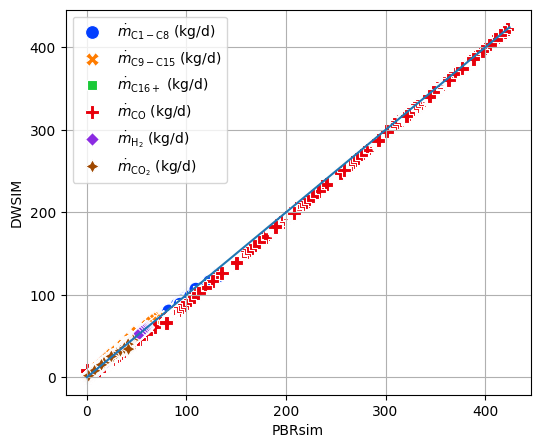

In [23]:
fig, ax = plt.subplots(figsize=(6,5))

max_xy = parity_data[['PBRsim', 'DWSIM']].max().max()

plt.plot((0, max_xy), (0, max_xy))
sns.scatterplot(data = parity_data,
            x = 'PBRsim', y = 'DWSIM', 
             hue = 'variable', style = 'variable', palette = 'bright', ax = ax, s = 100
            )
ax.grid('both')
ax.legend()
# ax.set_yscale('log')
# ax.set_xscale('log')

plt.show()